In [3]:
import numpy as np
import matplotlib.pyplot as plt

from qutip import Qobj, tensor, sigmax, qeye
from scipy.sparse import csc_matrix
from scipy.sparse.linalg import eigsh


## Crank-Nicolson and Hamiltonians

In [4]:
# ============================================================
# Core linear-algebra / dynamics utilities
# ============================================================

def crank_nicolson_propagator(H: Qobj, t: float, steps: int = 100) -> Qobj:
    """
    Crank–Nicolson approximation to U(t) = exp(-i H t).
    """
    dt = t / steps
    dim = H.shape[0]
    I = np.eye(dim, dtype=complex)

    A = I - 1j * (dt / 2) * H.full()
    B = I + 1j * (dt / 2) * H.full()

    lu, piv = lu_factor(A)
    U_step = lu_solve((lu, piv), B)
    U_total = np.linalg.matrix_power(U_step, steps)

    return Qobj(U_total, dims=H.dims)


def spin_chain_ham(h: float, g: float, J: float, J2: float, N: int) -> Qobj:
    """
    Spin-chain Hamiltonian used throughout the notebook:
      H = -J Σ σ^z_i σ^z_{i+1} + J2 Σ σ^z_i σ^z_{i+2} - h Σ σ^x_i - g Σ σ^z_i
    """
    sx = [tensor([sigmax() if i == j else qeye(2) for i in range(N)]) for j in range(N)]
    sz = [tensor([sigmaz() if i == j else qeye(2) for i in range(N)]) for j in range(N)]

    H = (
        sum(-J * sz[i] * sz[i + 1] for i in range(N - 1))
        + sum(J2 * sz[i] * sz[i + 2] for i in range(N - 2))
        - sum(h * sx[i] for i in range(N))
        - sum(g * sz[i] for i in range(N))
    )
    return H


def ground_state_ket(H: Qobj) -> Qobj:
    """
    Ground state ket via sparse eigensolver (smallest algebraic eigenvalue).
    """
    Hs = csc_matrix(H.full())
    evals, evecs = eigsh(Hs, k=1, which="SA")
    N = len(H.dims[0])
    psi = Qobj(evecs[:, 0], dims=[H.dims[0], [1] * N])
    return psi.unit()




## Parity operators

In [5]:


def parity_operator(N: int) -> Qobj:
    """Global Z2 spin-flip parity: P = ⊗_i σ^x_i."""
    return tensor([sigmax() for _ in range(N)])

def parity_expectation(P: Qobj, psi: Qobj) -> float:
    """Return <psi|P|psi> as real float (QuTiP returns scalar complex)."""
    return float(np.real(psi.dag() * P * psi))

def parity_label(val: float, tol: float = 1e-3) -> str:
    """Pretty label for parity expectation."""
    if abs(val - 1.0) < tol:
        return "+1"
    if abs(val + 1.0) < tol:
        return "-1"
    return f"{val:+.2f}"




## Lowest four eigenvalues

In [6]:
def lowest_four_eigenpairs(H: Qobj) -> tuple[list[float], list[Qobj]]:
    """
    Return ([E0,E1,E2,E3], [psi0,psi1,psi2,psi3]).
    Dense for dim<=16, sparse eigsh otherwise.
    """
    dim = H.shape[0]

    if dim <= 16:
        evals, evecs = np.linalg.eigh(H.full())
        idx = np.argsort(evals)
        evals = evals[idx]
        evecs = evecs[:, idx]
        if dim < 4:
            raise ValueError(f"Hilbert space dim={dim} < 4, cannot return 4 eigenpairs.")
        kets = [Qobj(evecs[:, j], dims=[H.dims[0], [1] * len(H.dims[0])]) for j in range(4)]
        return [float(evals[j]) for j in range(4)], kets

    Hs = csc_matrix(H.full())
    k = min(4, dim - 1)
    evals, vecs = eigsh(Hs, k=k, which="SA")
    idx = np.argsort(evals)
    evals = evals[idx]
    vecs = vecs[:, idx]
    if k < 4:
        raise ValueError(f"Requested 4 eigenpairs but dim={dim} only supports k={k} with eigsh.")
    kets = [Qobj(vecs[:, j], dims=[H.dims[0], [1] * len(H.dims[0])]) for j in range(4)]
    return [float(evals[j]) for j in range(4)], kets


## Plotting E vs h

In [7]:
def plot_lowest_four_energies_vs_h_separate_with_parity(
    *,
    h_list: np.ndarray,
    g_fixed: float,
    J: float,
    J2: float = 0.0,
    Ns=(1, 2, 3, 4),
    parity_tol: float = 1e-3,
    annotate: bool = False,   # dense sweeps: keep False by default
    print_table: bool = True,
):
    Ns = list(Ns)
    valid_Ns = [N for N in Ns if 2**N >= 4]
    if len(valid_Ns) == 0:
        raise ValueError("No N in Ns has Hilbert space dimension >= 4. Use N>=2.")

    n_plots = len(valid_Ns)
    fig, axes = plt.subplots(n_plots, 1, figsize=(7, 3 * n_plots), sharex=True)
    if n_plots == 1:
        axes = [axes]

    for ax, N in zip(axes, valid_Ns):
        P = parity_operator(N)

        E_lists = [[] for _ in range(4)]
        Par_lists = [[] for _ in range(4)]

        for h in h_list:
            H = spin_chain_ham(h=h, g=g_fixed, J=J, J2=J2, N=N)
            Es, kets = lowest_four_eigenpairs(H)

            for lvl in range(4):
                E_lists[lvl].append(Es[lvl])
                Par_lists[lvl].append(parity_expectation(P, kets[lvl]))

        # Plot energies
        ax.plot(h_list, E_lists[0], "o-", markersize=3, label=r"$E_0$")
        ax.plot(h_list, E_lists[1], "x--", markersize=3, label=r"$E_1$")
        ax.plot(h_list, E_lists[2], "s-", markersize=3, label=r"$E_2$")
        ax.plot(h_list, E_lists[3], "d--", markersize=3, label=r"$E_3$")

        # Optional annotation
        if annotate:
            for lvl in range(4):
                for hh, EE, pp in zip(h_list, E_lists[lvl], Par_lists[lvl]):
                    ax.text(hh, EE, parity_label(pp, tol=parity_tol),
                            fontsize=6, ha="center", va="bottom")

        ax.set_ylabel("Energy")
        ax.set_title(f"Sweep h (g={g_fixed}), N={N} | parity ⟨⊗σx⟩")
        ax.legend(ncol=2)
        ax.grid(True)

        # Print table
        if print_table:
            print(f"\n=== Parity ⟨P⟩ for Sweep h (g={g_fixed}), N={N} ===")
            print("NOTE: In this model, exact Z2 parity is a good quantum number only when g=0.\n")
            header = "h".ljust(10) + "  " + "  ".join([f"E{lvl}".ljust(12) for lvl in range(4)]) \
                     + " | " + "  ".join([f"⟨P⟩{lvl}".ljust(12) for lvl in range(4)])
            print(header)
            for i, hh in enumerate(h_list):
                energies = "  ".join([f"{E_lists[lvl][i]: .6f}".ljust(12) for lvl in range(4)])
                pars     = "  ".join([f"{Par_lists[lvl][i]:+.6f}".ljust(12) for lvl in range(4)])
                print(f"{hh: .4f}".ljust(10) + "  " + energies + " | " + pars)

    axes[-1].set_xlabel(r"Transverse field $h$")
    plt.tight_layout()
    return fig, axes




## Set Parameters for plotting and parity tables

NameError: name 'sigmaz' is not defined

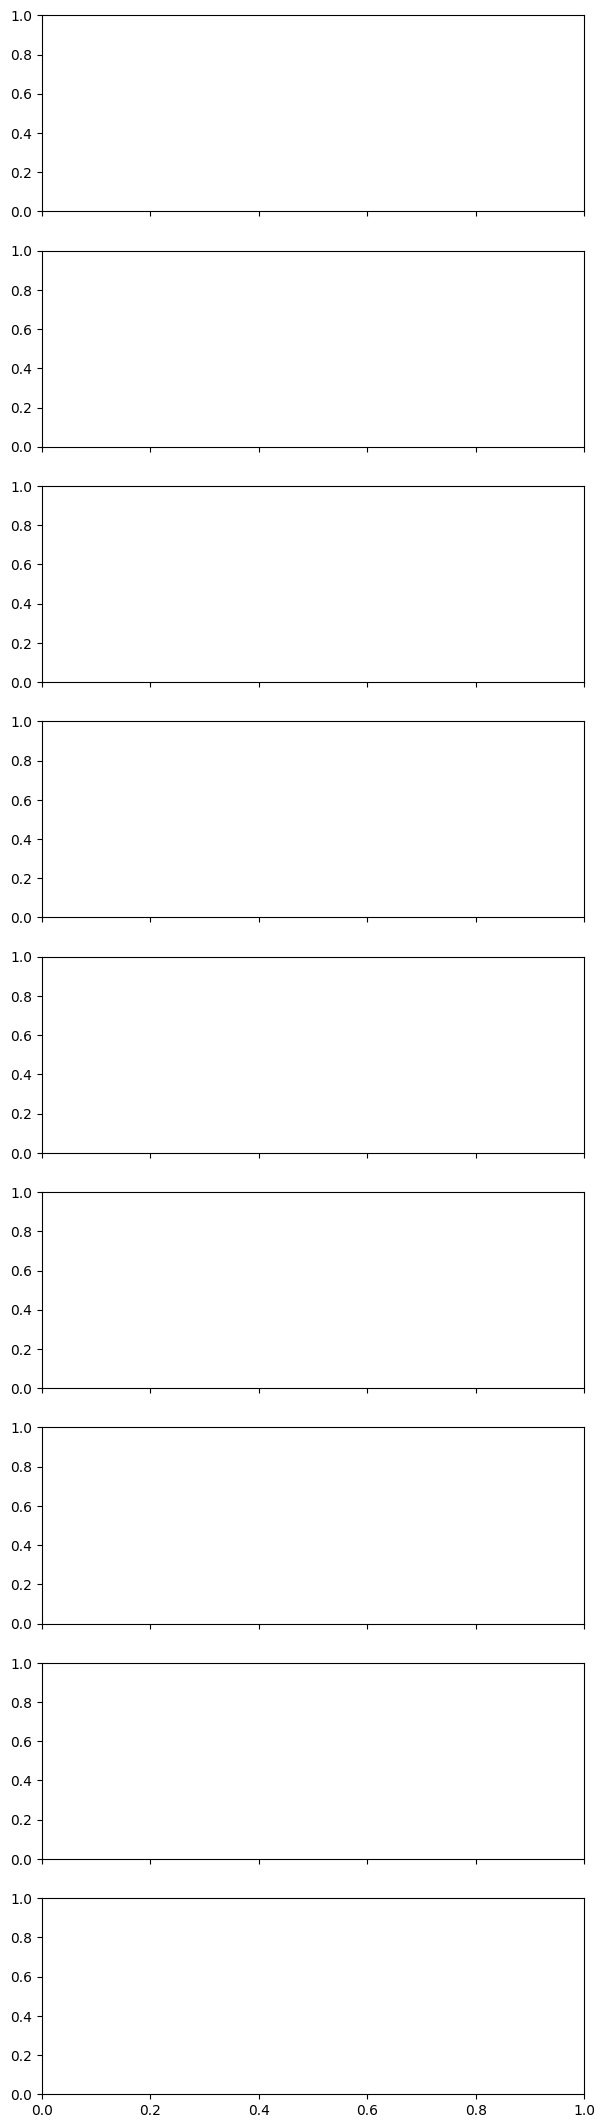

In [9]:
h_list = np.linspace(-5.0, 5.0, 41)
fig, axes = plot_lowest_four_energies_vs_h_separate_with_parity(
    h_list=h_list,
    g_fixed=0.4,
    J=1.0,
    J2=0.0,
    Ns=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10),
    annotate=False,
    print_table=True,
)
#plt.savefig("E_vs_h_with_parity_(fixed_g=0.4).pdf")
plt.show()


h_list = np.linspace(-5.0, 5.0, 41)
fig, axes = plot_lowest_four_energies_vs_h_separate_with_parity(
    h_list=h_list,
    g_fixed=0.0,
    J=1.0,
    J2=0.0,
    Ns=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10),
    annotate=False,
    print_table=True,
)
#plt.savefig("E_vs_h_with_parity_(fixed_g=0.0).pdf")
plt.show()


## Plotting E vs g (fixed h)

In [ ]:


def plot_lowest_four_energies_vs_g_separate_with_parity(
    *,
    g_list: np.ndarray,
    h_fixed: float,
    J: float,
    J2: float = 0.0,
    Ns=(1, 2, 3, 4),
    parity_tol: float = 1e-3,
    annotate: bool = False,   # dense sweeps: keep False by default
    print_table: bool = True,
):
    Ns = list(Ns)
    valid_Ns = [N for N in Ns if 2**N >= 4]
    if len(valid_Ns) == 0:
        raise ValueError("No N in Ns has Hilbert space dimension >= 4. Use N>=2.")

    n_plots = len(valid_Ns)
    fig, axes = plt.subplots(n_plots, 1, figsize=(7, 3 * n_plots), sharex=True)
    if n_plots == 1:
        axes = [axes]

    for ax, N in zip(axes, valid_Ns):
        P = parity_operator(N)

        E_lists = [[] for _ in range(4)]
        Par_lists = [[] for _ in range(4)]

        for g in g_list:
            H = spin_chain_ham(h=h_fixed, g=g, J=J, J2=J2, N=N)
            Es, kets = lowest_four_eigenpairs(H)

            for lvl in range(4):
                E_lists[lvl].append(Es[lvl])
                Par_lists[lvl].append(parity_expectation(P, kets[lvl]))

        # Plot energies
        ax.plot(g_list, E_lists[0], "o-", markersize=3, label=r"$E_0$")
        ax.plot(g_list, E_lists[1], "x--", markersize=3, label=r"$E_1$")
        ax.plot(g_list, E_lists[2], "s-", markersize=3, label=r"$E_2$")
        ax.plot(g_list, E_lists[3], "d--", markersize=3, label=r"$E_3$")

        # Optional annotation
        if annotate:
            for lvl in range(4):
                for gg, EE, pp in zip(g_list, E_lists[lvl], Par_lists[lvl]):
                    ax.text(gg, EE, parity_label(pp, tol=parity_tol),
                            fontsize=6, ha="center", va="bottom")

        ax.set_ylabel("Energy")
        ax.set_title(f"Sweep g (h={h_fixed}), N={N} | parity ⟨⊗σx⟩")
        ax.legend(ncol=2)
        ax.grid(True)

        # Print table
        if print_table:
            print(f"\n=== Parity ⟨P⟩ for Sweep g (h={h_fixed}), N={N} ===")
            print("NOTE: In this model, exact Z2 parity is a good quantum number only when g=0.\n")
            header = "g".ljust(10) + "  " + "  ".join([f"E{lvl}".ljust(12) for lvl in range(4)]) \
                     + " | " + "  ".join([f"⟨P⟩{lvl}".ljust(12) for lvl in range(4)])
            print(header)
            for i, gg in enumerate(g_list):
                energies = "  ".join([f"{E_lists[lvl][i]: .6f}".ljust(12) for lvl in range(4)])
                pars     = "  ".join([f"{Par_lists[lvl][i]:+.6f}".ljust(12) for lvl in range(4)])
                print(f"{gg: .4f}".ljust(10) + "  " + energies + " | " + pars)

    axes[-1].set_xlabel(r"Longitudinal field $g$")
    plt.tight_layout()
    return fig, axes






## Parameters for plotting and parity tables

In [ ]:

g_list = np.linspace(-5.0, 5.0, 41)
fig, axes = plot_lowest_four_energies_vs_g_separate_with_parity(
    g_list=g_list,
    h_fixed=1.0,
    J=1.0,
    J2=0.0,
    Ns=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10),
    annotate=False,      # set True only if g_list is small (else messy)
    print_table=True,    # prints parity expectations
)
#plt.savefig("E_vs_g_with_parity_(fixed_h=1.0).pdf")
plt.show()